In [80]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Sklearn - Train/Test Split and Regression Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

# CatBoost
from catboost import CatBoostRegressor


In [81]:
df=pd.read_csv("/kaggle/input/affair-dataset/affairs.csv")

In [82]:
df.head()

,Unnamed: 0,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [83]:
df.drop(columns=["Unnamed: 0"],axis=1,inplace=True)

In [84]:
df.shape

(6366, 9)

In [85]:
df.isnull().sum()

rate_marriage      0
age                0
yrs_married        0
children           0
religious          0
educ               0
occupation         0
occupation_husb    0
affairs            0
dtype: int64

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6366 entries, 0 to 6365
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rate_marriage    6366 non-null   float64
 1   age              6366 non-null   float64
 2   yrs_married      6366 non-null   float64
 3   children         6366 non-null   float64
 4   religious        6366 non-null   float64
 5   educ             6366 non-null   float64
 6   occupation       6366 non-null   float64
 7   occupation_husb  6366 non-null   float64
 8   affairs          6366 non-null   float64
dtypes: float64(9)
memory usage: 447.7 KB


In [87]:
df.describe()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
count,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000
mean,4.109645,29.082862,9.009425,1.396874,2.426170,14.209865,3.424128,3.850141,0.705374
std,0.961430,6.847882,7.280120,1.433471,0.878369,2.178003,0.942399,1.346435,2.203374
min,1.000000,17.500000,0.500000,0.000000,1.000000,9.000000,1.000000,1.000000,0.000000
25%,4.000000,22.000000,2.500000,0.000000,2.000000,12.000000,3.000000,3.000000,0.000000
50%,4.000000,27.000000,6.000000,1.000000,2.000000,14.000000,3.000000,4.000000,0.000000
75%,5.000000,32.000000,16.500000,2.000000,3.000000,16.000000,4.000000,5.000000,0.484848
max,5.000000,42.000000,23.000000,5.500000,4.000000,20.000000,6.000000,6.000000,57.599991


In [88]:
df.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


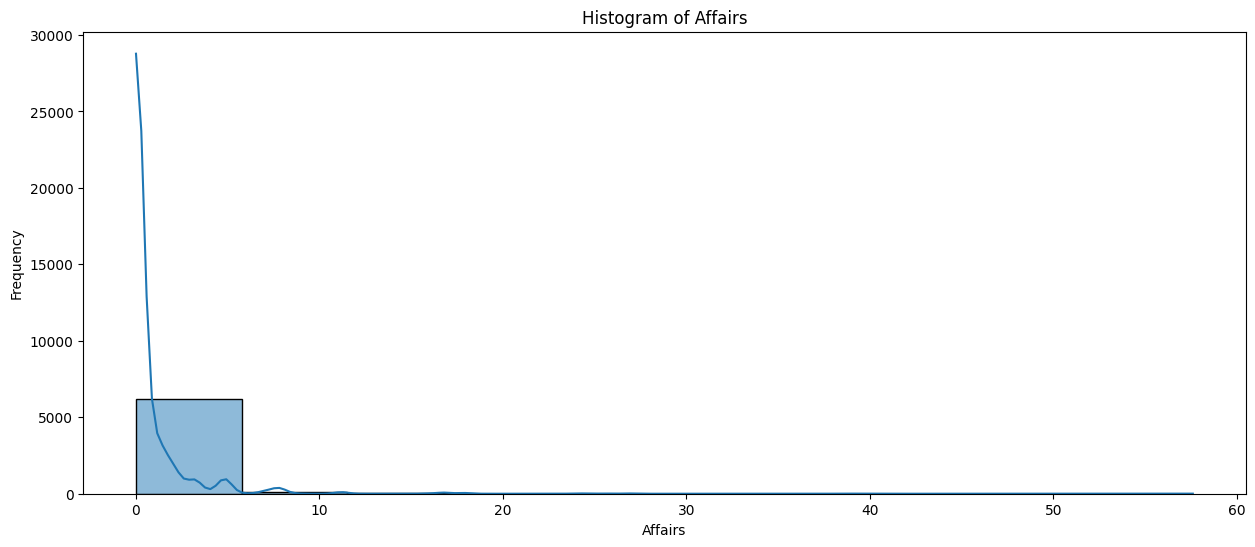

In [89]:
plt.figure(figsize=(15, 6))
sns.histplot(df['affairs'], bins=10, kde=True)
plt.title('Histogram of Affairs')
plt.xlabel('Affairs')
plt.ylabel('Frequency')
plt.show()

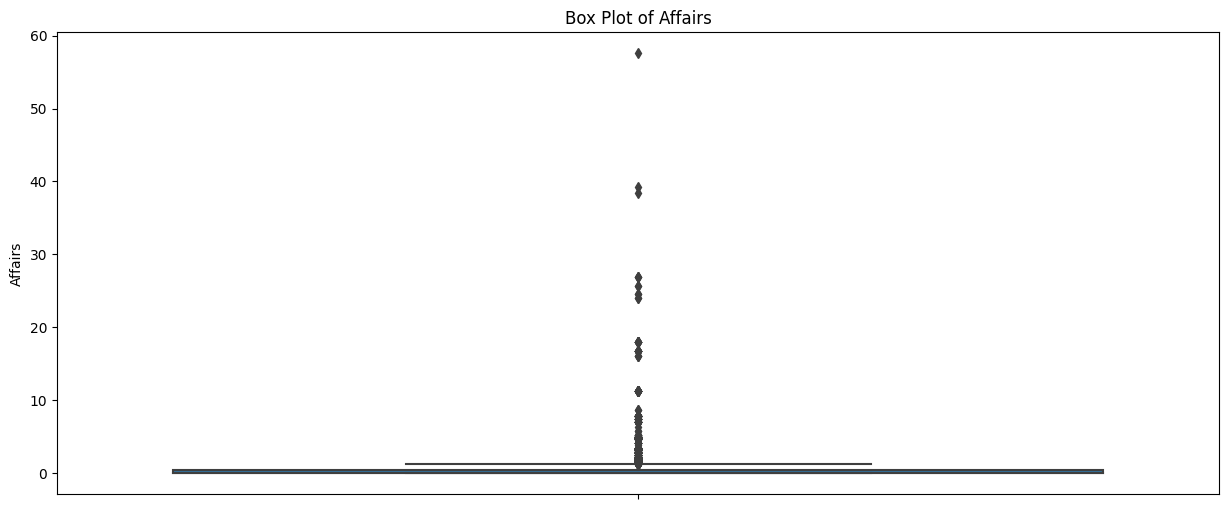

In [90]:
plt.figure(figsize=(15, 6))
sns.boxplot(y=df['affairs'])
plt.title('Box Plot of Affairs')
plt.ylabel('Affairs')
plt.show()

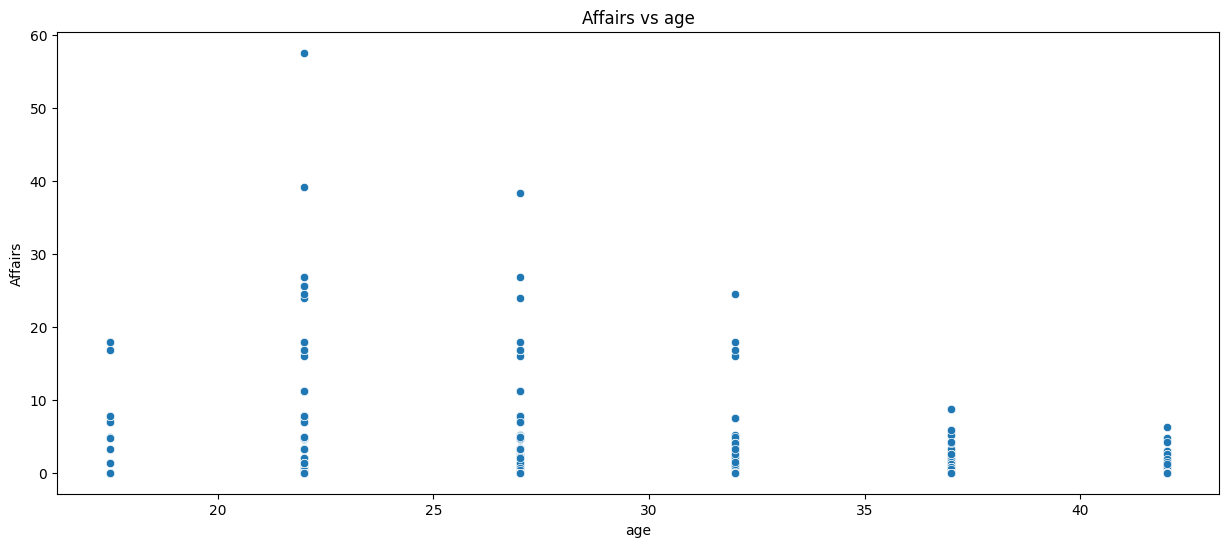

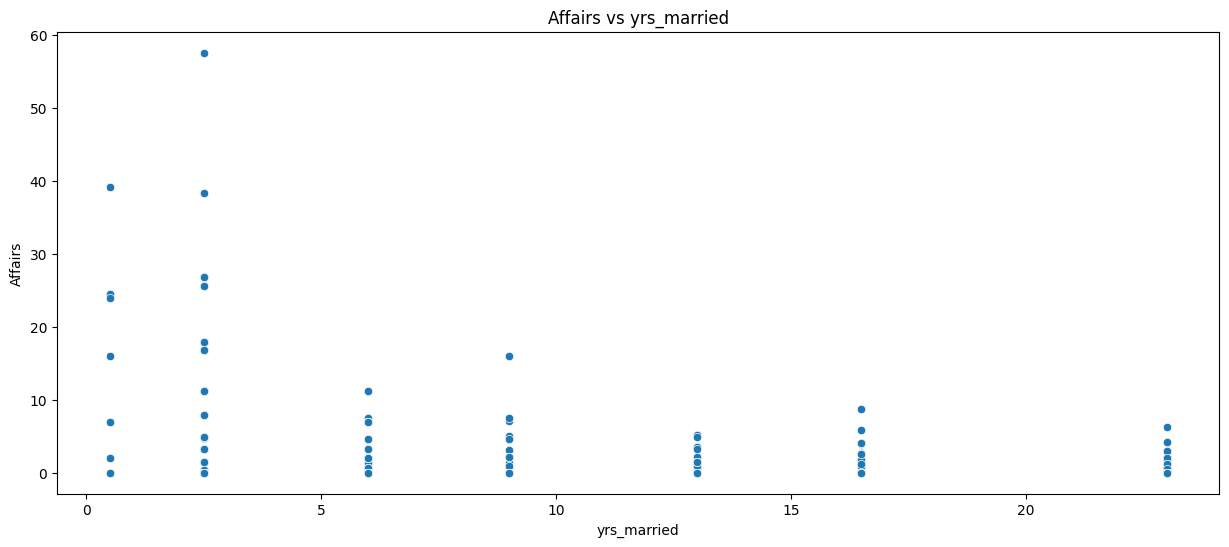

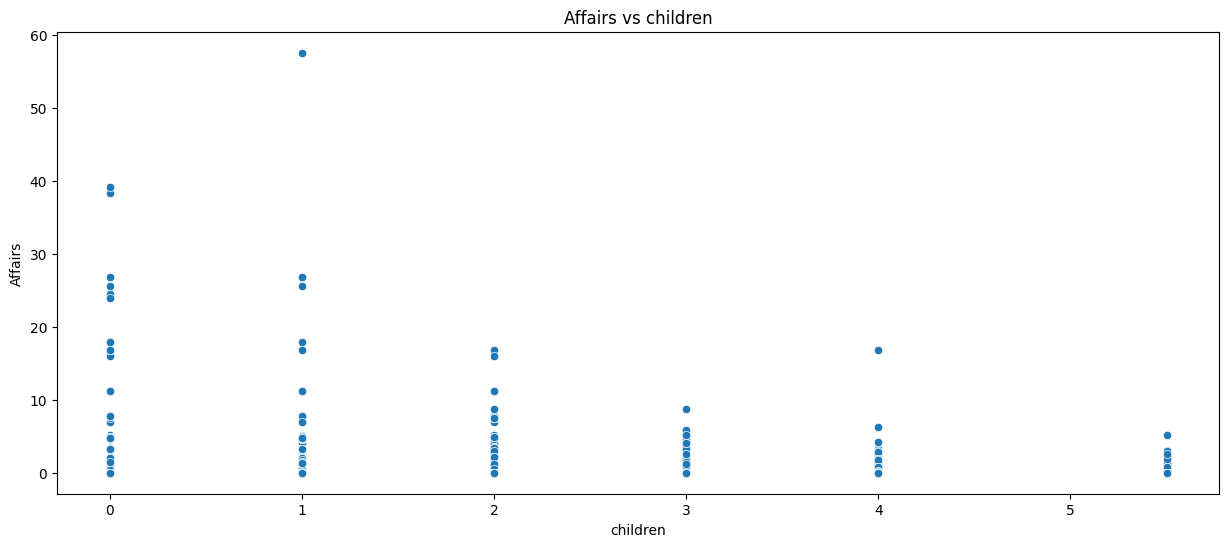

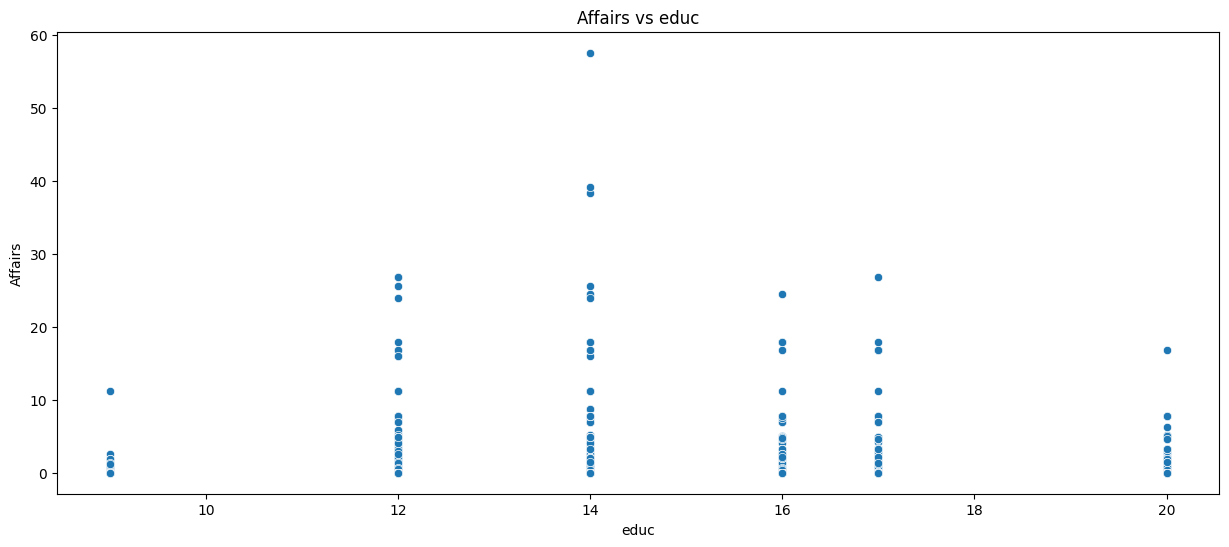

In [91]:
continuous_vars = ['age', 'yrs_married', 'children', 'educ']
for var in continuous_vars:
    plt.figure(figsize=(15, 6))
    sns.scatterplot(x=df[var], y=df['affairs'])
    plt.title(f'Affairs vs {var}')
    plt.xlabel(var)
    plt.ylabel('Affairs')
    plt.show()

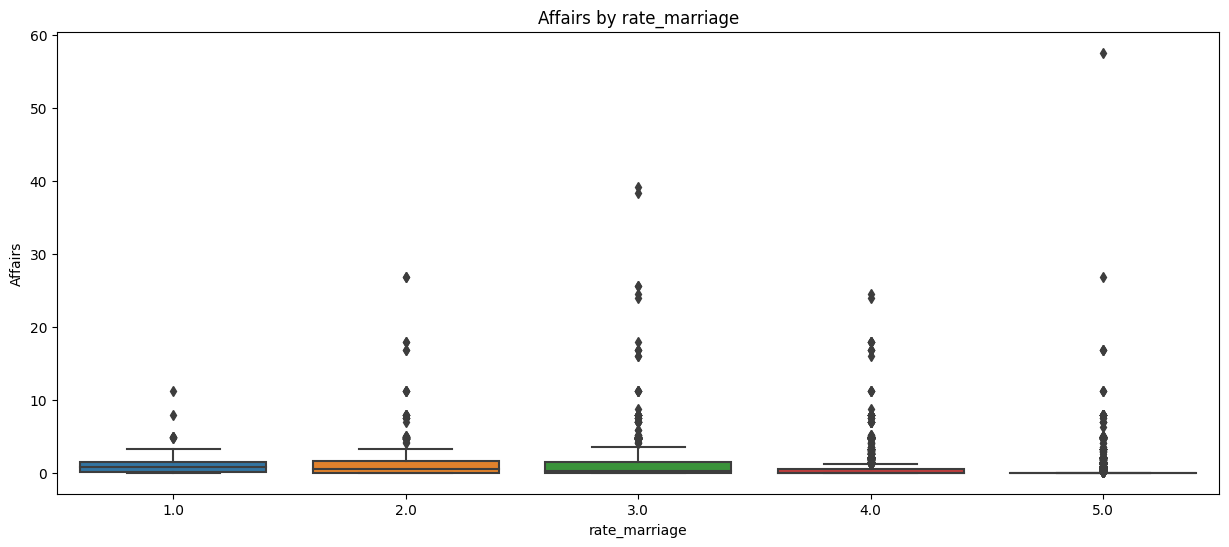

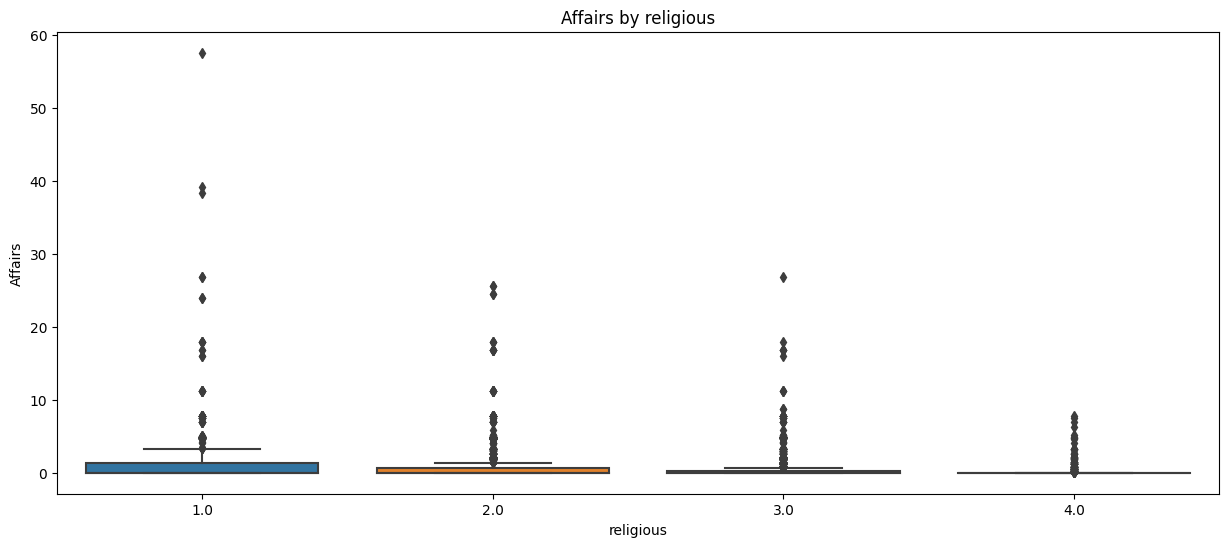

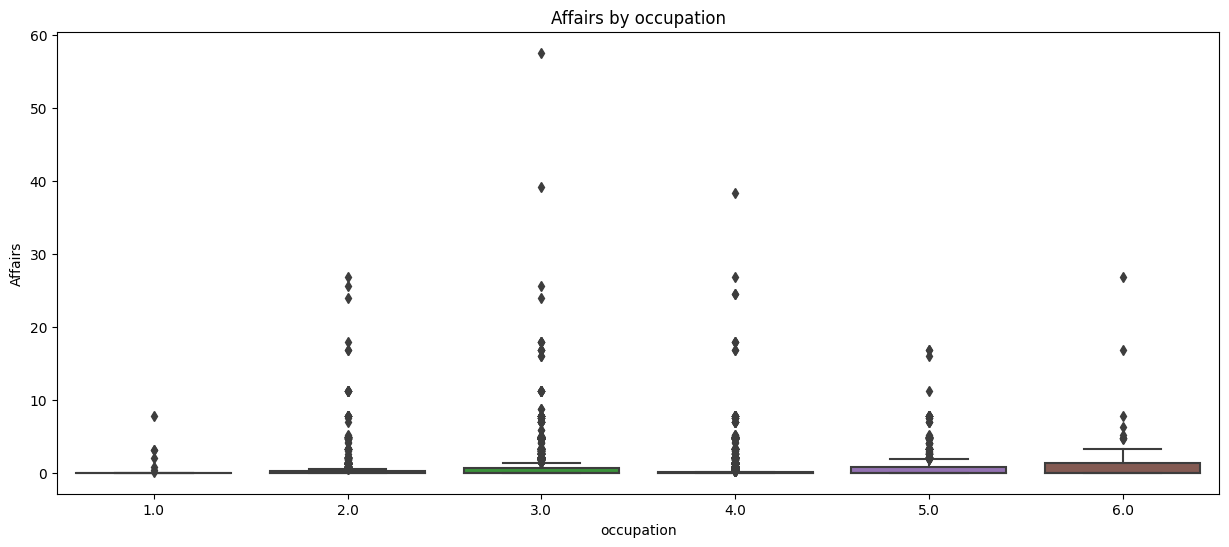

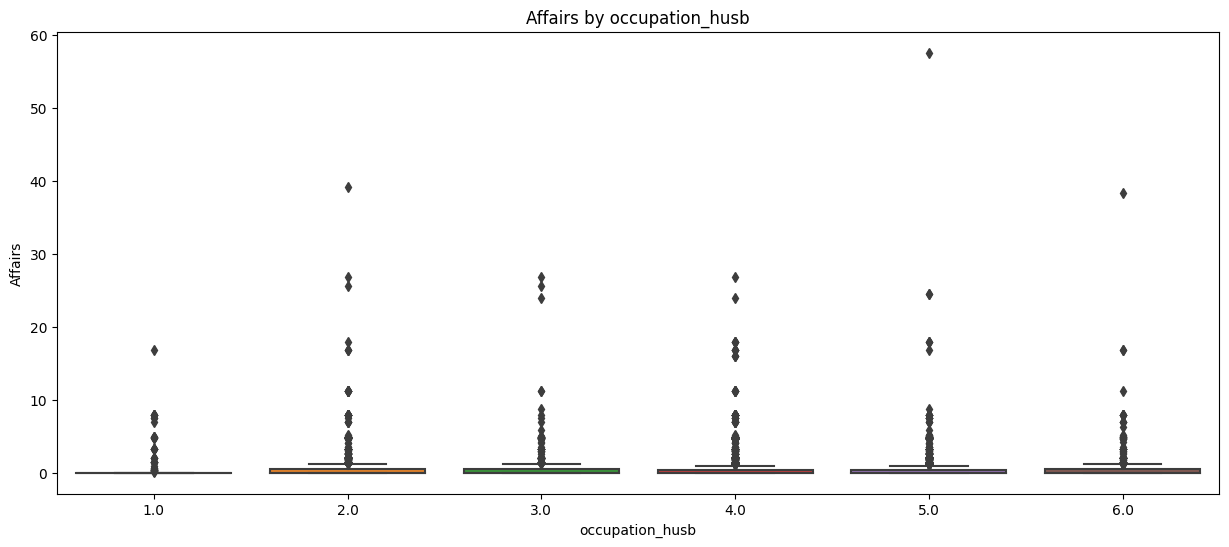

In [92]:
categorical_vars = ['rate_marriage', 'religious', 'occupation', 'occupation_husb']
for var in categorical_vars:
    plt.figure(figsize=(15, 6))
    sns.boxplot(x=df[var], y=df['affairs'])
    plt.title(f'Affairs by {var}')
    plt.xlabel(var)
    plt.ylabel('Affairs')
    plt.show()

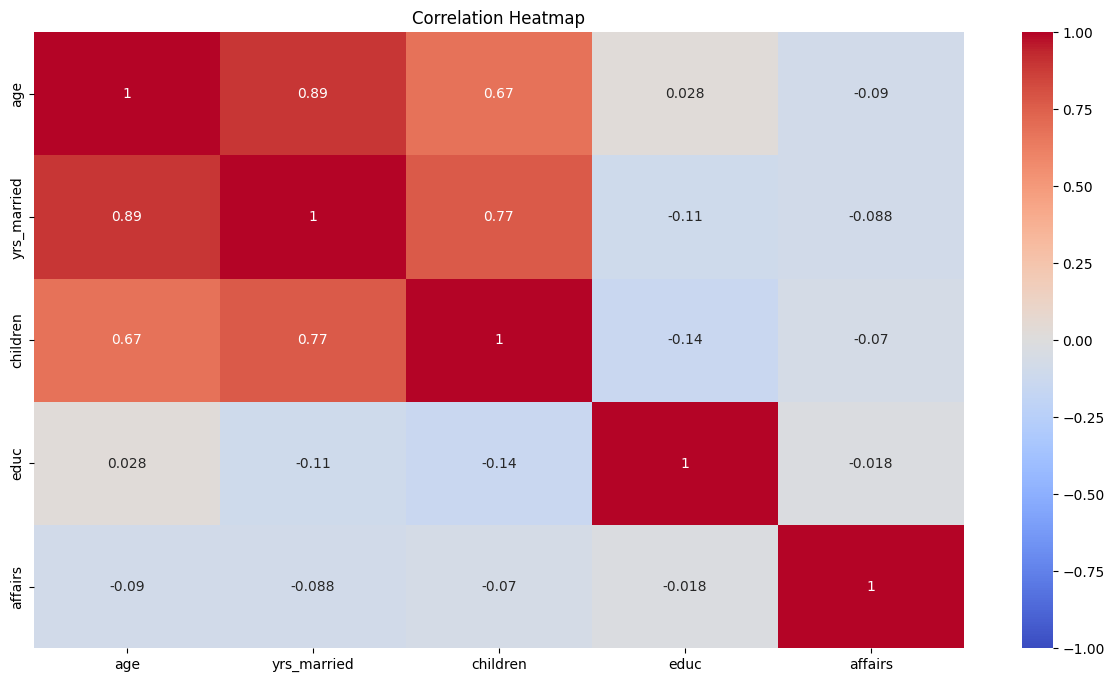

In [93]:
plt.figure(figsize=(15, 8))
corr = df[continuous_vars + ['affairs']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

In [94]:
df.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [95]:
X = df.drop('affairs', axis=1)
y = df['affairs']

In [96]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
top5_features = importance_df.sort_values(by='Importance', ascending=False)['Feature'].head(5).tolist()
df = df[top5_features + ['affairs']]
df.head()

,occupation_husb,educ,occupation,yrs_married,age,affairs
0,5.0,17.0,2.0,9.0,32.0,0.111111
1,4.0,14.0,3.0,13.0,27.0,3.230769
2,5.0,16.0,3.0,2.5,22.0,1.400000
3,5.0,16.0,5.0,16.5,37.0,0.727273
4,4.0,14.0,3.0,9.0,27.0,4.666666


In [97]:
X = df.drop('affairs', axis=1)
y = df['affairs']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [98]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5092, 5)
X_test shape: (1274, 5)
y_train shape: (5092,)
y_test shape: (1274,)


In [99]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(learning_rate=0.1,n_estimators=1000,random_state=42,max_depth=6)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

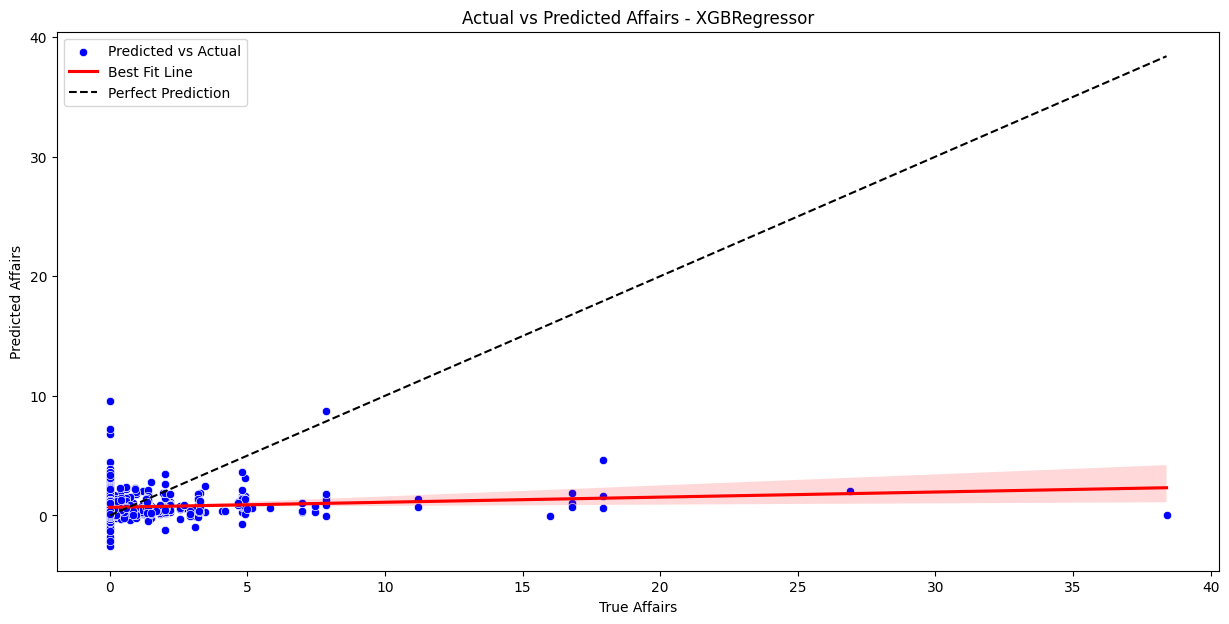

In [100]:
plt.figure(figsize=(15,7))
sns.scatterplot(x=y_test, y=y_pred, color='blue', label='Predicted vs Actual')
sns.regplot(x=y_test, y=y_pred, scatter=False, color='red', label='Best Fit Line')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', label='Perfect Prediction')

plt.xlabel('True Affairs')
plt.ylabel('Predicted Affairs')
plt.title('Actual vs Predicted Affairs - XGBRegressor')
plt.legend()
plt.show()

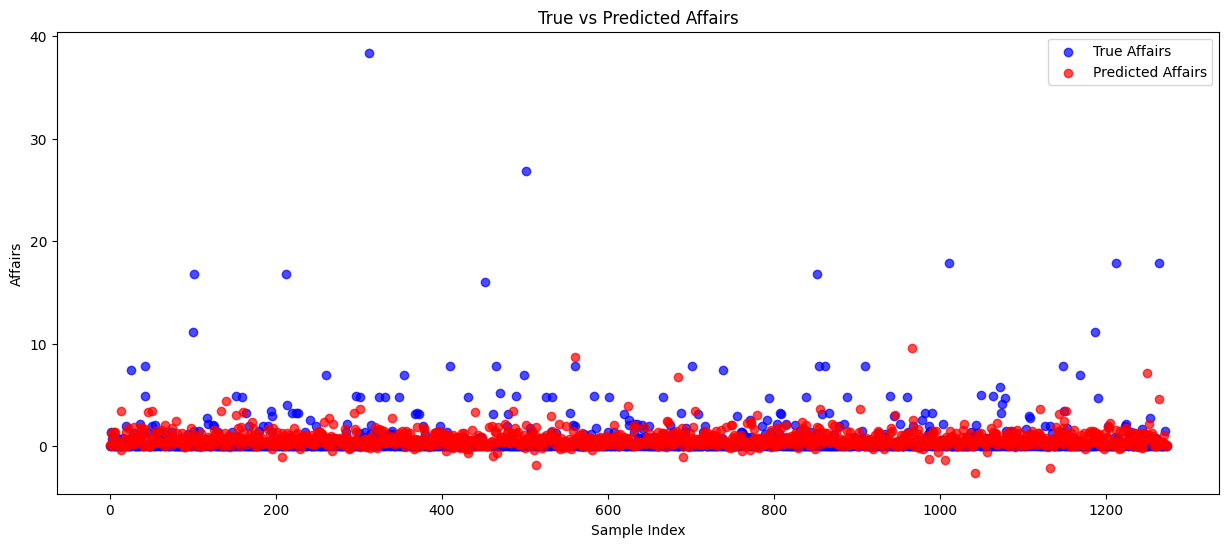

In [101]:

plt.figure(figsize=(15, 6))


indices = range(len(y_test))

# Plot true values
plt.scatter(indices, y_test, color='blue', label='True Affairs', alpha=0.7)


plt.scatter(indices, y_pred, color='red', label='Predicted Affairs', alpha=0.7)

plt.xlabel('Sample Index')
plt.ylabel('Affairs')
plt.title('True vs Predicted Affairs')
plt.legend()
plt.show()


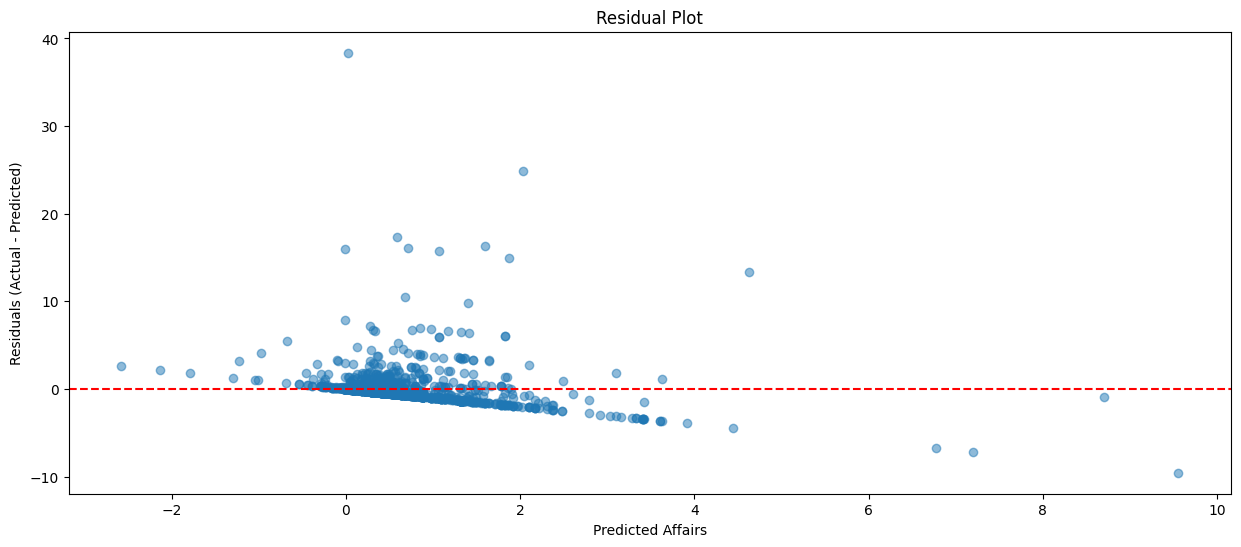

In [102]:
residuals = y_test - y_pred
plt.figure(figsize=(15, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Affairs')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()


use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


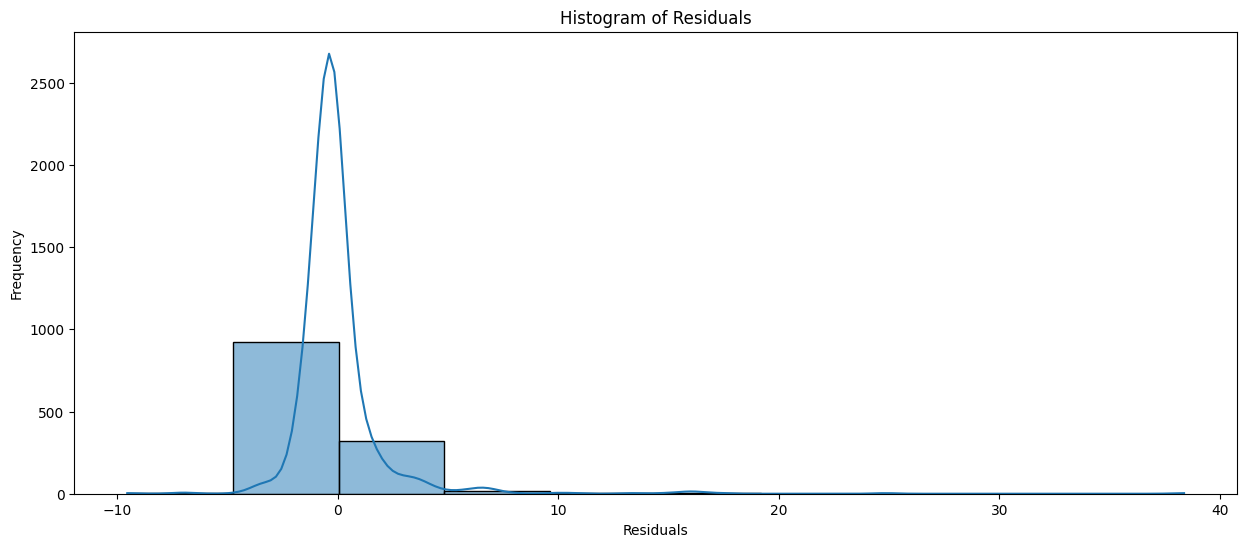

In [103]:
plt.figure(figsize=(15, 6))
sns.histplot(residuals, bins=10, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()

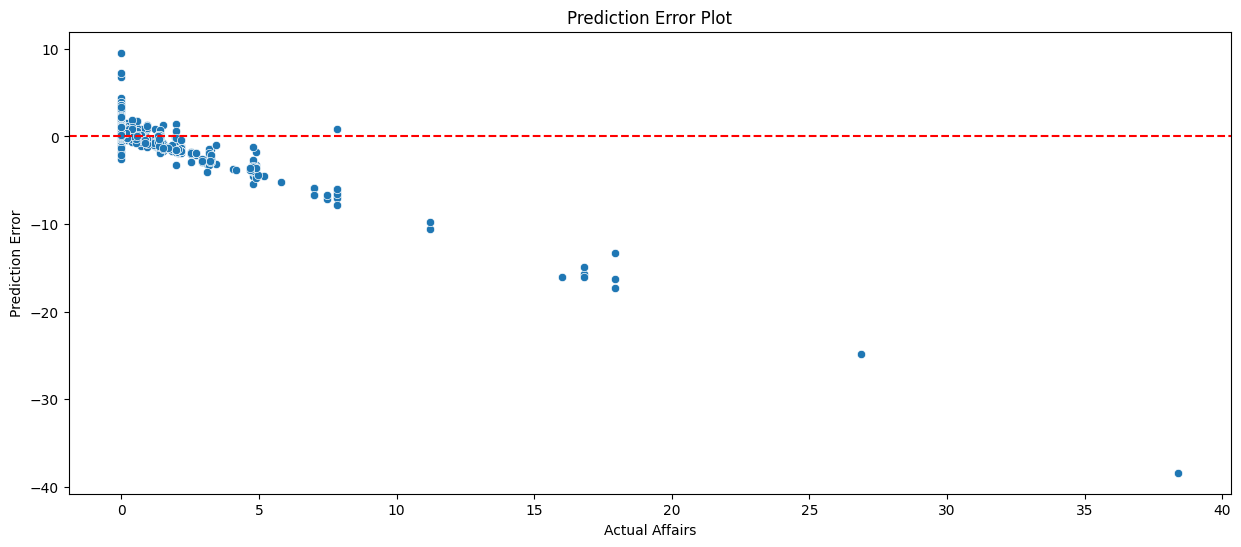

In [104]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x=y_test, y=y_pred - y_test)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Actual Affairs')
plt.ylabel('Prediction Error')
plt.title('Prediction Error Plot')
plt.show()


<Figure size 1500x600 with 0 Axes>

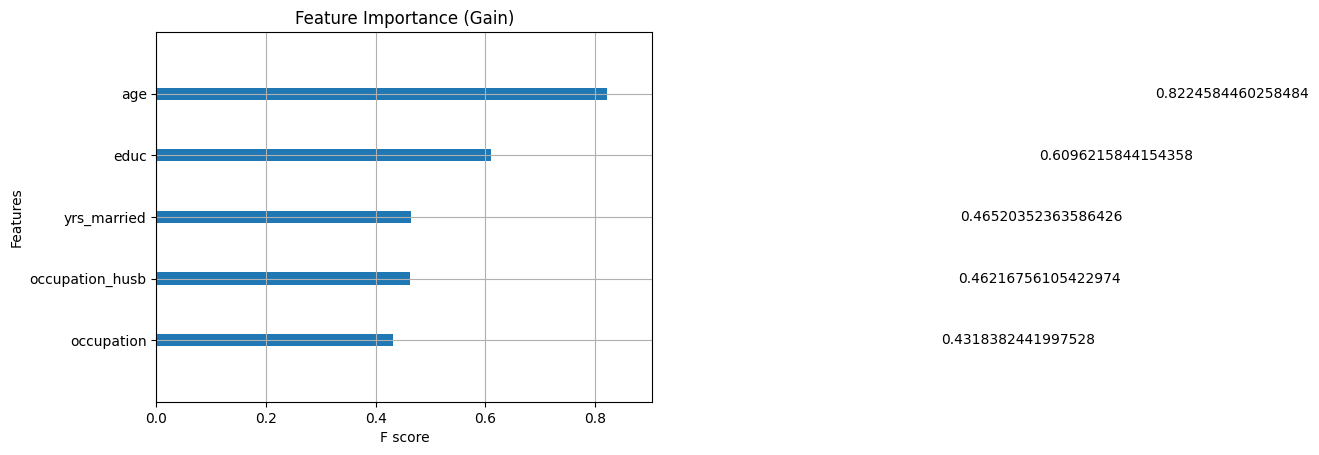

In [105]:
from xgboost import XGBRegressor, plot_importance
plt.figure(figsize=(15, 6))
plot_importance(xgb_model, importance_type='gain', max_num_features=8)
plt.title('Feature Importance (Gain)')
plt.show()

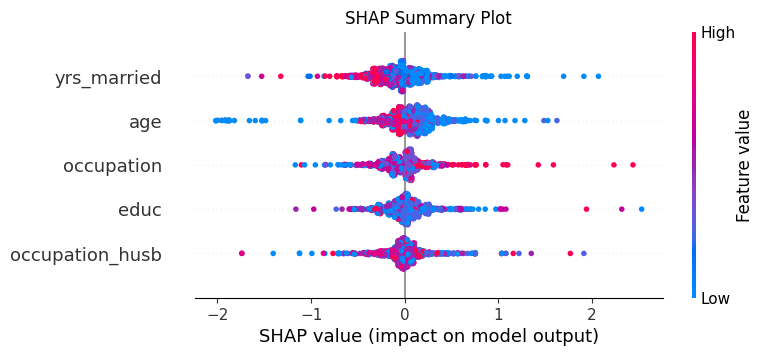

In [106]:
import plotly.express as px
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
plt.figure(figsize=(15, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot')
plt.show()

<Figure size 1500x600 with 0 Axes>

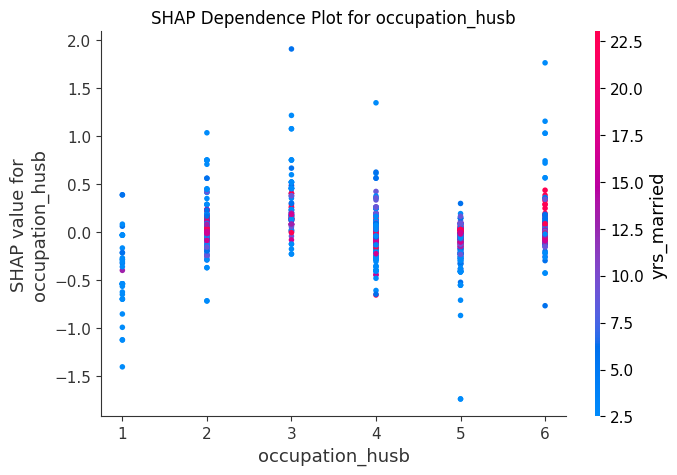

<Figure size 1500x600 with 0 Axes>

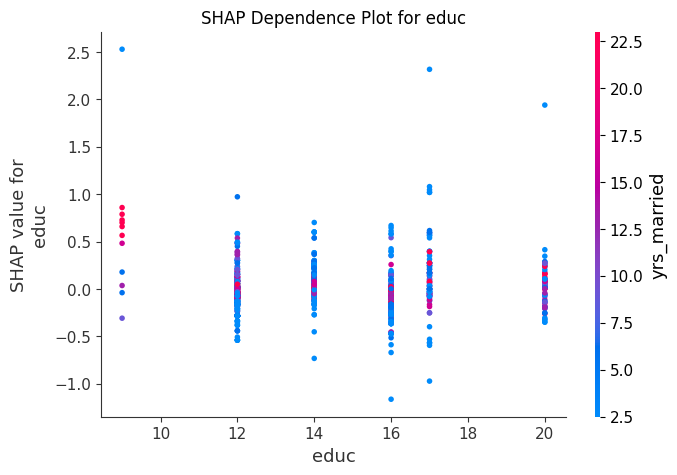

<Figure size 1500x600 with 0 Axes>

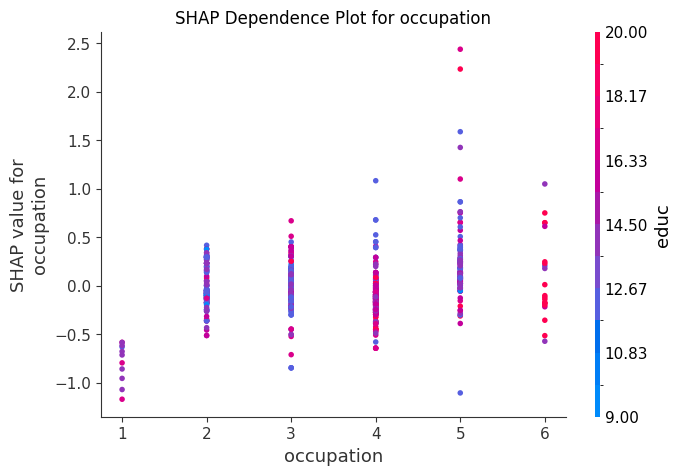

<Figure size 1500x600 with 0 Axes>

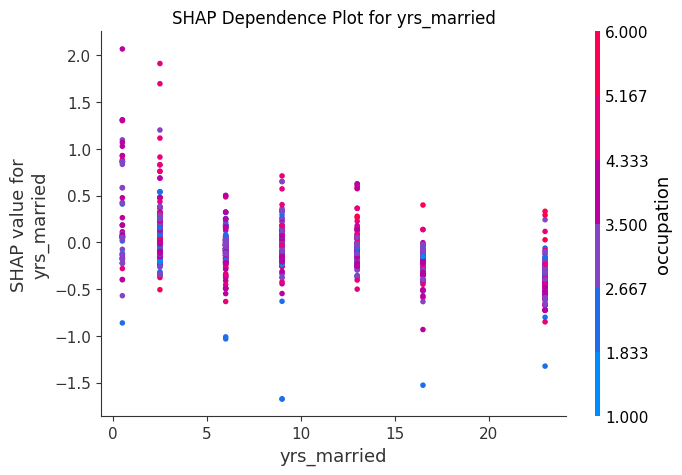

<Figure size 1500x600 with 0 Axes>

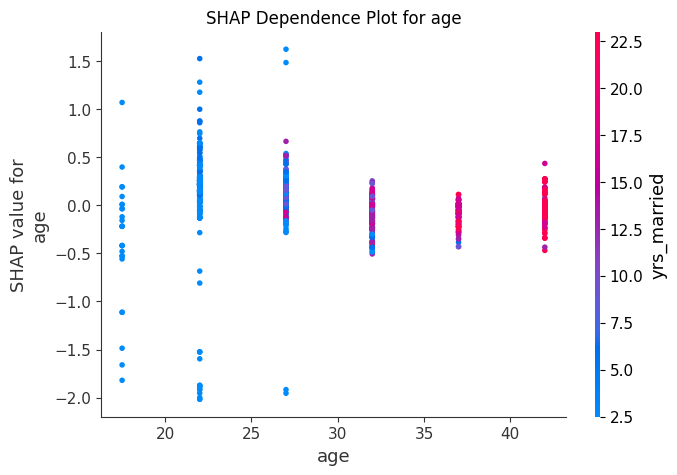

In [107]:
for feature in X_test.columns:
    plt.figure(figsize=(15, 6))
    shap.dependence_plot(feature, shap_values, X_test, show=False)
    plt.title(f'SHAP Dependence Plot for {feature}')
    plt.show()

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


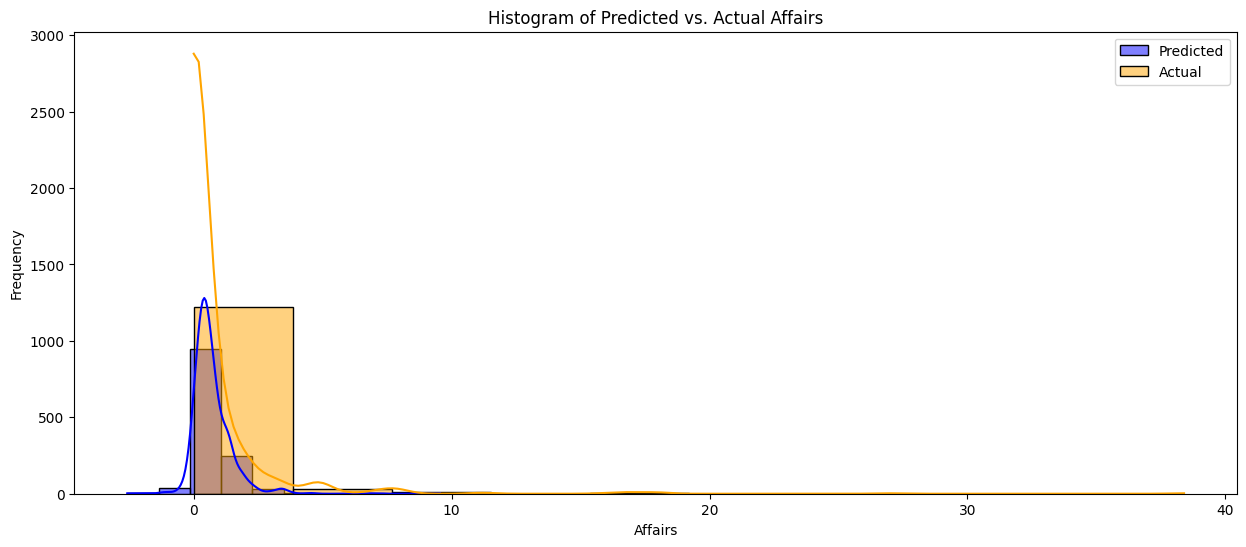

In [108]:
plt.figure(figsize=(15, 6))
sns.histplot(y_pred, bins=10, kde=True, color='blue', label='Predicted')
sns.histplot(y_test, bins=10, kde=True, color='orange', alpha=0.5, label='Actual')
plt.xlabel('Affairs')
plt.ylabel('Frequency')
plt.title('Histogram of Predicted vs. Actual Affairs')
plt.legend()
plt.show()

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


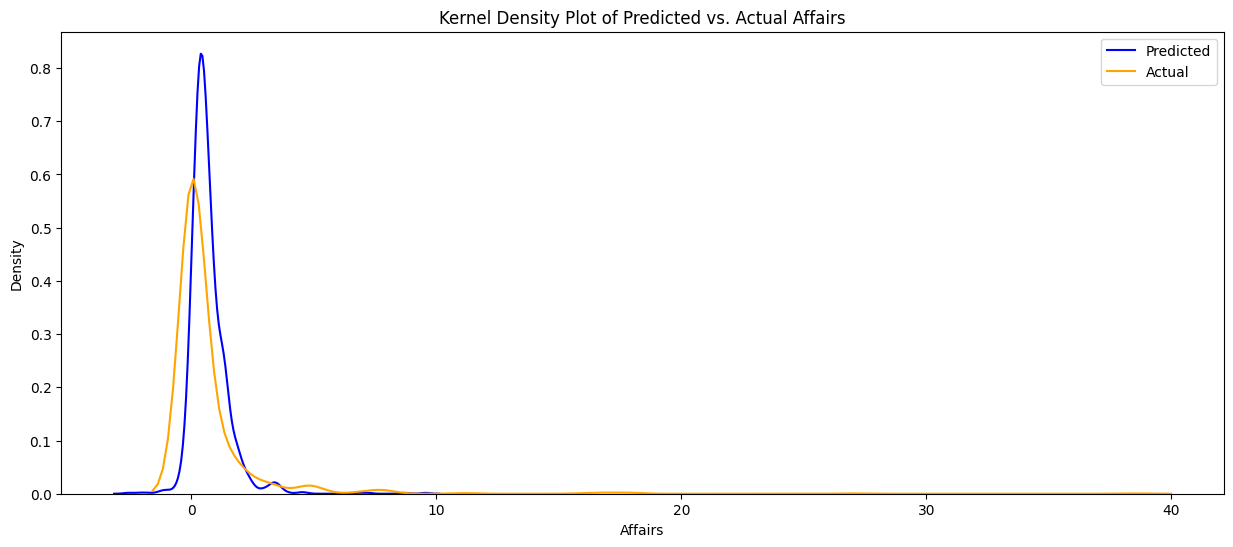

In [109]:
plt.figure(figsize=(15, 6))
sns.kdeplot(y_pred, label='Predicted', color='blue')
sns.kdeplot(y_test, label='Actual', color='orange')
plt.xlabel('Affairs')
plt.ylabel('Density')
plt.title('Kernel Density Plot of Predicted vs. Actual Affairs')
plt.legend()
plt.show()

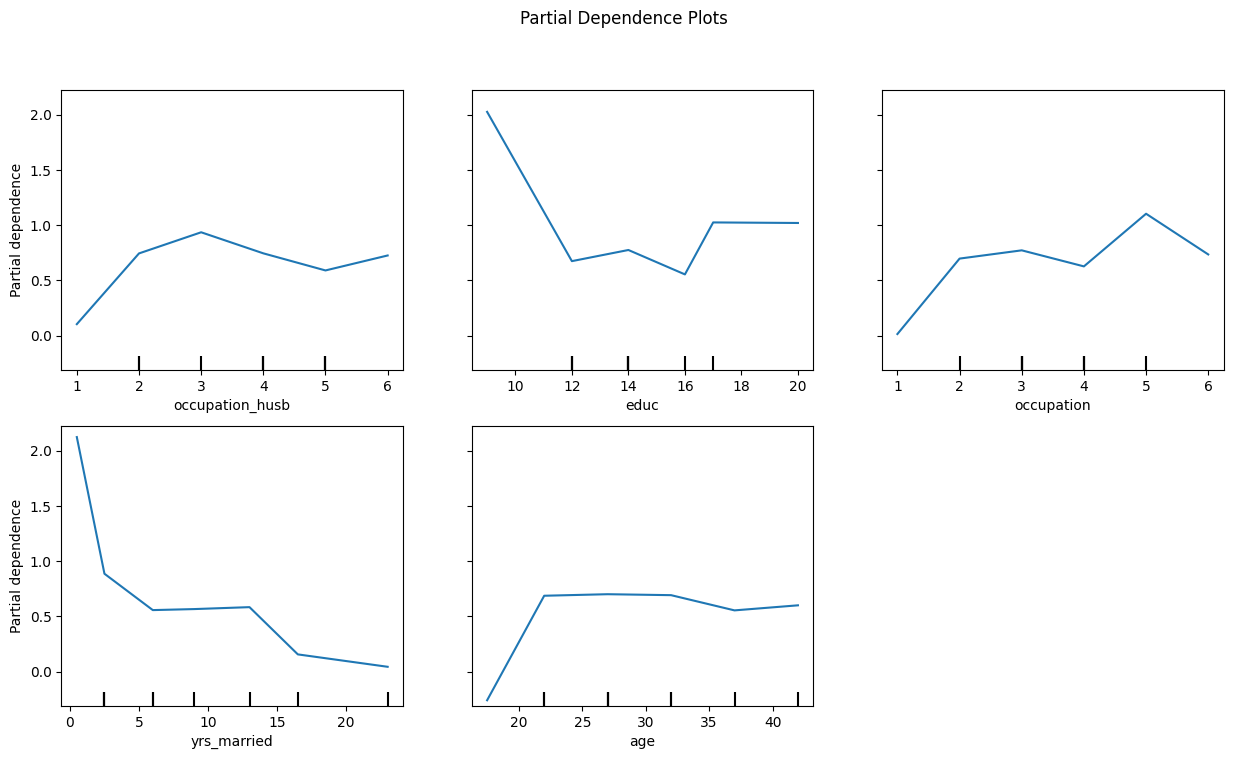

In [110]:
from sklearn.inspection import partial_dependence
from sklearn.inspection import PartialDependenceDisplay
fig, ax = plt.subplots(figsize=(15, 8))
PartialDependenceDisplay.from_estimator(xgb_model, X_test, features=X_test.columns, ax=ax)
plt.suptitle('Partial Dependence Plots')
plt.show()

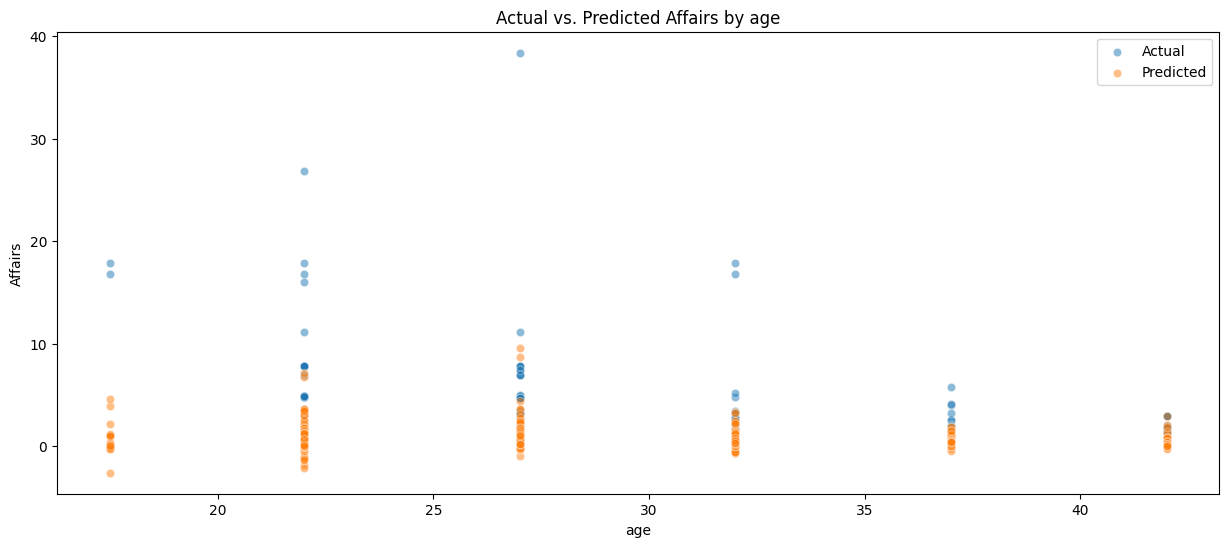

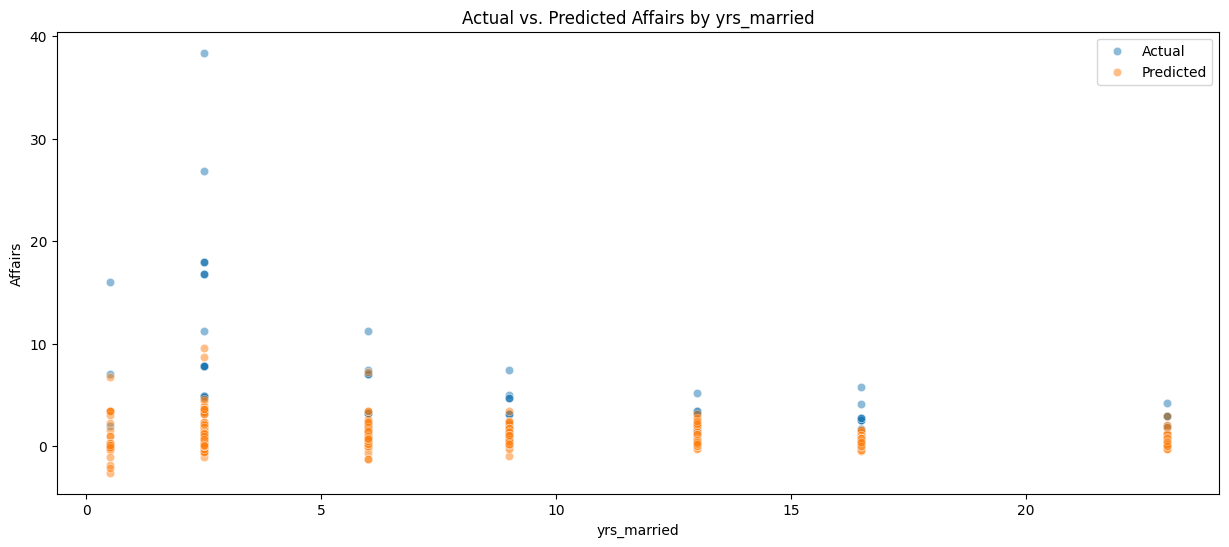

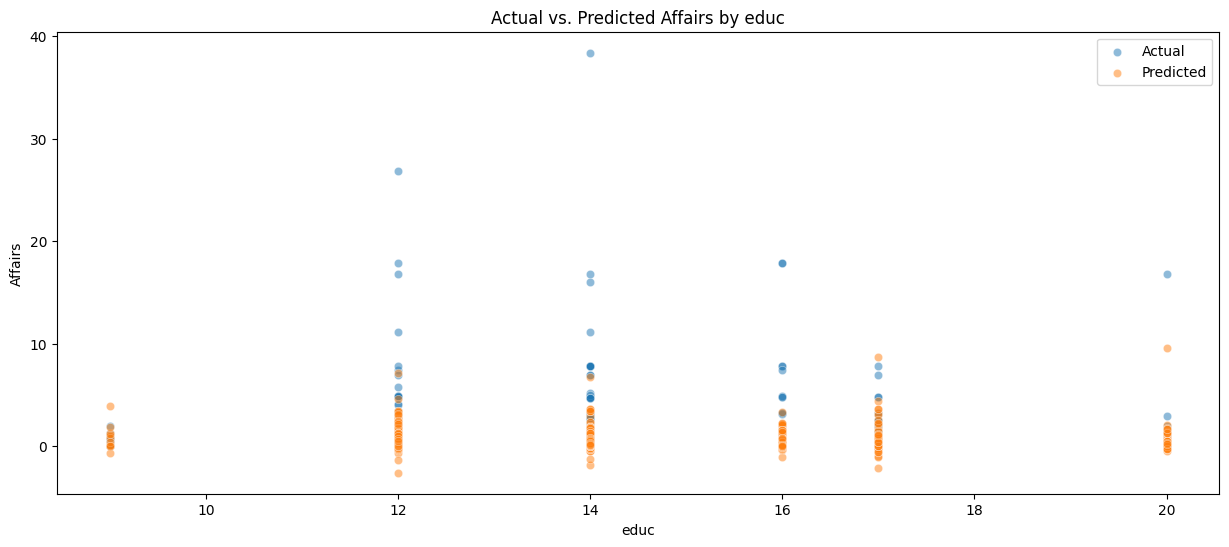

In [111]:
continuous_vars = ['age', 'yrs_married', 'educ']

for var in continuous_vars:
    plt.figure(figsize=(15, 6))
    sns.scatterplot(x=X_test[var], y=y_test, label='Actual', alpha=0.5)
    sns.scatterplot(x=X_test[var], y=y_pred, label='Predicted', alpha=0.5)
    plt.xlabel(var)
    plt.ylabel('Affairs')
    plt.title(f'Actual vs. Predicted Affairs by {var}')
    plt.legend()
    plt.show()